In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("place.csv")

In [30]:
df.iloc[:10,:]

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
5,5,7.1,48.0,1
6,6,5.7,143.0,0
7,7,5.0,63.0,0
8,8,6.1,156.0,0
9,9,5.1,66.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [33]:
df = df.iloc[:,1:]

In [34]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


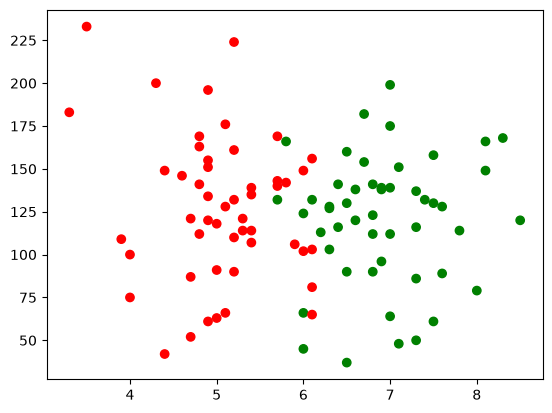

In [37]:
colors = df['placement'].map({0:'red', 1:'green'})

plt.scatter(df['cgpa'], df['iq'],c=colors)

In [58]:
X = df.iloc[:,0:2]
y = df.iloc[:,2]

In [59]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train, y_test = train_test_split(X,y,test_size=0.1)
y_test

62    0
77    1
72    1
79    1
81    0
76    0
20    1
90    1
45    1
26    1
Name: placement, dtype: int64

In [60]:
from sklearn.preprocessing import StandardScaler

In [61]:
scaler = StandardScaler()

In [73]:
X_train = scaler.fit_transform(X_train)
X_train

array([[ 0.91249713,  1.26761475],
       [-1.15787452,  0.52961018],
       [-1.67546743, -0.64101777],
       [-0.0364232 , -0.48832716],
       [ 0.56743519,  0.32602271],
       [ 0.30863874, -0.56467247],
       [-0.20895418,  0.45326488],
       [ 0.82623165,  0.35147114],
       [-0.98534354,  1.11492415],
       [-0.98534354,  0.40236801],
       [ 0.91249713,  0.35147114],
       [ 0.73996616, -0.33563656],
       [-0.89907806,  1.80203186],
       [-0.55401612, -0.10660066],
       [-0.46775063,  0.35147114],
       [ 0.99876262,  0.65685235],
       [-0.6402816 ,  0.17333211],
       [-2.27932583,  1.47120222],
       [-1.33040549, -2.11702692],
       [-1.07160903, -1.86254258],
       [-0.89907806,  0.65685235],
       [ 1.25755908,  0.17333211],
       [ 0.82623165, -0.7428115 ],
       [-0.98534354,  0.96223355],
       [ 0.48116971, -2.24426908],
       [-0.12268869,  1.03857885],
       [ 0.39490422, -0.23384283],
       [-0.6402816 ,  0.91133668],
       [ 1.43009005,

In [63]:
X_test = scaler.transform(X_test)

In [64]:
from sklearn.linear_model import LogisticRegression

In [65]:
clf = LogisticRegression()

In [66]:
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [67]:
y_pred = clf.predict(X_test)
y_pred

array([1, 1, 1, 1, 0, 0, 1, 1, 1, 1])

In [68]:
from sklearn.metrics import accuracy_score

In [69]:
accuracy_score(y_test,y_pred)

0.9

In [20]:
!pip install mlxtend

  Using cached mlxtend-0.25.0-py3-none-any.whl.metadata (7.4 kB)
Using cached mlxtend-0.25.0-py3-none-any.whl (1.4 MB)


In [70]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

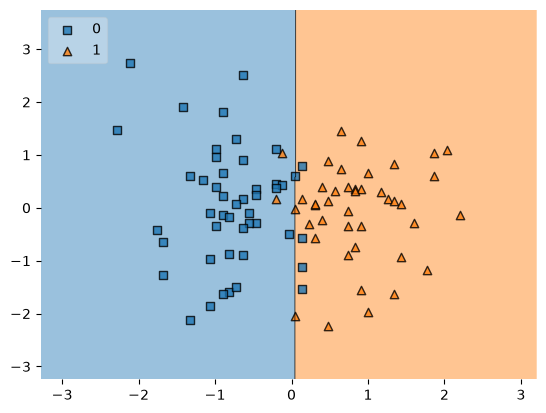

In [75]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [23]:
import pickle

In [76]:
pickle.dump(clf,open('model.pkl','wb'))